Using device: cpu
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReL

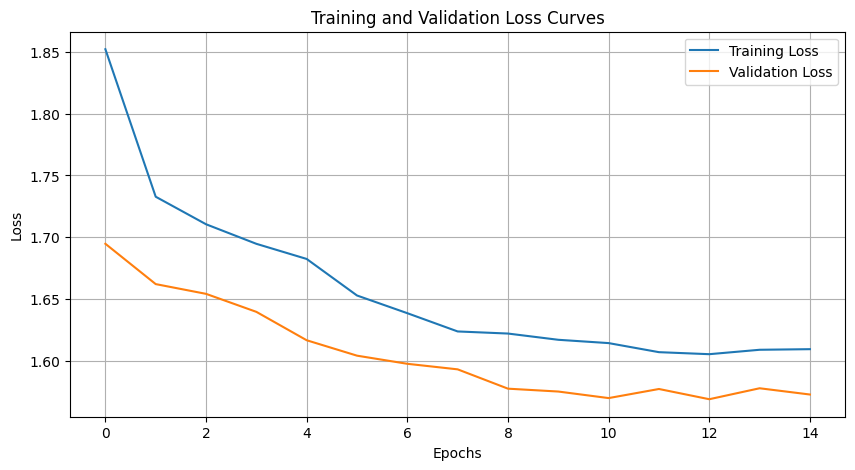

              precision    recall  f1-score   support

       plane       0.43      0.59      0.49      1000
         car       0.52      0.48      0.50      1000
        bird       0.38      0.36      0.37      1000
         cat       0.38      0.35      0.36      1000
        deer       0.46      0.44      0.45      1000
         dog       0.39      0.43      0.41      1000
        frog       0.46      0.60      0.52      1000
       horse       0.52      0.43      0.47      1000
        ship       0.47      0.45      0.46      1000
       truck       0.53      0.37      0.43      1000

    accuracy                           0.45     10000
   macro avg       0.45      0.45      0.45     10000
weighted avg       0.45      0.45      0.45     10000



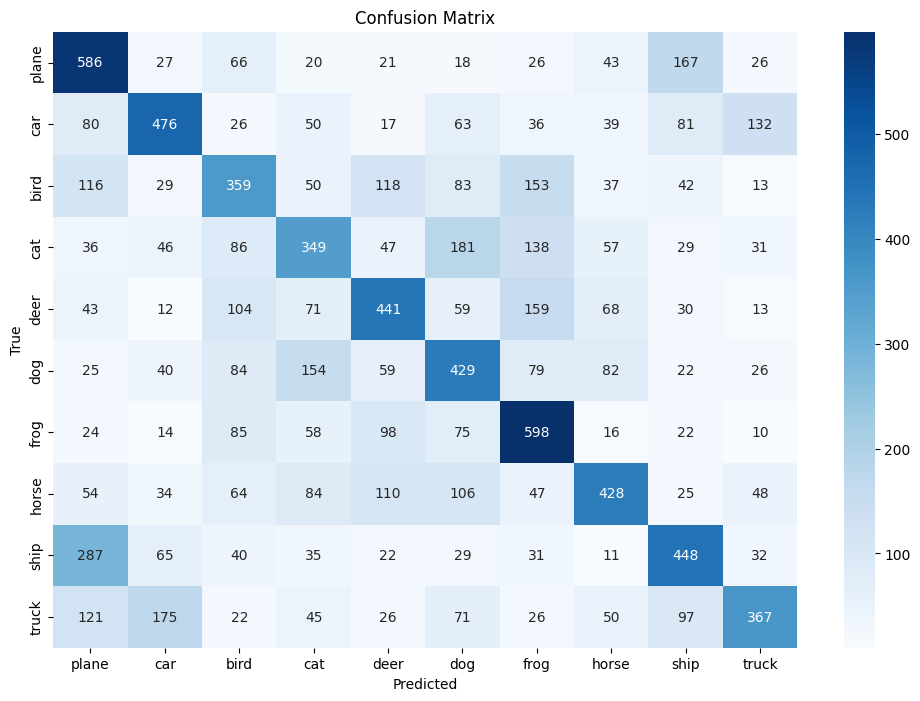

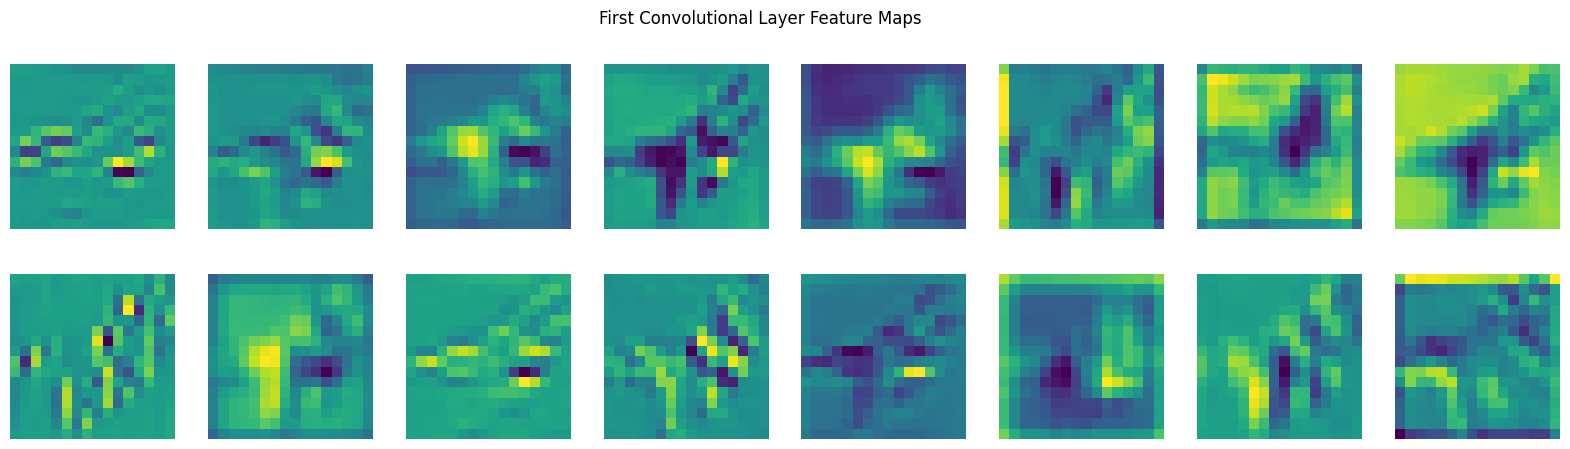

Model saved to saved_models\cifar10_resnet.pth


In [ ]:
# %% [markdown]
# ## 进阶实践：CIFAR-10图像分类（CNN+迁移学习）
# 使用ResNet预训练模型和PyTorch实现

# %% [code]
# 1. 环境配置与数据增强
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os

# 自动选择设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 数据增强与标准化
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 更强的数据增强
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=5, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# %% [code]
# 2. 加载CIFAR-10数据集
train_dataset = datasets.CIFAR10(
    root='../data', 
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root='../data', 
    train=False,
    download=True,
    transform=test_transform
)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

# 创建数据加载器
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# %% [code]
# 3. 定义迁移学习模型（基于ResNet18）
# 解冻更多层进行微调
def create_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # 只冻结前几层，允许后面的层参与训练
    ct = 0
    for child in model.children():
        ct += 1
        if ct < 6:  # 冻结前5层
            for param in child.parameters():
                param.requires_grad = False
    
    # 替换最后的全连接层
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 10)
    )
    return model.to(device)

model = create_model()
print(model)  # 查看模型结构

# %% [code]
# 4. 训练配置（含学习率调度器）
criterion = nn.CrossEntropyLoss()
# 改进优化器和学习率调度
optimizer = optim.SGD(
    [
        {'params': [p for n, p in model.named_parameters() if 'fc' not in n and p.requires_grad], 'lr': 0.0001},
        {'params': model.fc.parameters(), 'lr': 0.001}
    ], 
    momentum=0.9, weight_decay=5e-4
)
# 余弦退火学习率
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

# %% [code]
# 5. 训练过程（含验证损失跟踪）
def train_model(model, epochs=15):
    train_loss, val_loss = [], []
    
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)  # 梯度裁剪
            optimizer.step()
            
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader)
        train_loss.append(epoch_loss)
        
        # 验证阶段
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
        
        val_epoch_loss = running_val_loss / len(test_loader)
        val_loss.append(val_epoch_loss)
        
        # 更新学习率
        scheduler.step()
        
        print(f"Epoch {epoch+1}/{epochs} => "
              f"Train Loss: {epoch_loss:.4f}, "
              f"Val Loss: {val_epoch_loss:.4f}, "
              f"LR: {scheduler.get_last_lr()[0]:.6f}")
    
    return train_loss, val_loss

# 执行训练
train_loss, val_loss = train_model(model, epochs=15)

# %% [code]
# 6. 可视化训练曲线
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# %% [code]
# 7. 模型评估与混淆矩阵
def evaluate_model(model):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 分类报告
    print(classification_report(all_labels, all_preds, target_names=classes))
    
    # 混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

evaluate_model(model)

# %% [code]
# 8. 特征可视化（卷积层输出）
def visualize_features(image_idx=5):
    # 获取测试图像
    image, label = test_dataset[image_idx]
    image = image.unsqueeze(0).to(device)
    
    # 提取中间层特征
    activation = {}
    def get_activation(name):
        def hook(model, input, output):
            activation[name] = output.detach()
        return hook
    
    # 注册钩子（选取第一个卷积层）
    model.conv1.register_forward_hook(get_activation('conv1'))
    
    # 前向传播
    with torch.no_grad():
        output = model(image)
    
    # 可视化特征图
    act = activation['conv1'].squeeze().cpu().numpy()
    plt.figure(figsize=(20, 5))
    for i in range(16):  # 显示前16个通道
        plt.subplot(2, 8, i+1)
        plt.imshow(act[i], cmap='viridis')
        plt.axis('off')
    plt.suptitle('First Convolutional Layer Feature Maps')
    plt.show()

visualize_features(image_idx=10)  # 尝试修改索引查看不同样本

# %% [code]
# 9. 保存模型（可选）
save_dir = './saved_models'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 保存模型
save_path = os.path.join(save_dir, 'cifar10_resnet.pth')
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

In [2]:
# 加载保存的模型并测试
loaded_model = create_model()
loaded_model.load_state_dict(torch.load(os.path.join(save_dir, 'cifar10_resnet.pth')))
loaded_model.to(device)
loaded_model.eval()

# 计算测试集准确率
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = loaded_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'测试集准确率: {100 * correct / total:.2f}%')

# 可视化一些测试样本的预测结果
def show_random_predictions(num_samples=5):
    # 获取随机样本
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    images, labels = images[:num_samples].to(device), labels[:num_samples].to(device)
    
    # 获取预测结果
    outputs = loaded_model(images)
    _, predicted = torch.max(outputs, 1)
    
    # 显示图像和预测
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        img = images[i].cpu().numpy().transpose((1, 2, 0))
        # 反标准化
        mean = np.array((0.4914, 0.4822, 0.4465))
        std = np.array((0.2023, 0.1994, 0.2010))
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        plt.imshow(img)
        plt.title(f'True: {classes[labels[i]]}\nPred: {classes[predicted[i]]}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

show_random_predictions(8)

NameError: name 'create_model' is not defined

## CNN

Using device: cpu
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)
Epoch [1/10] Loss: 1.2883
Epoch [2/10] Loss: 0.8911
Epoch [3/10] Loss: 0.7049
Epoch [4/10] Loss: 0.5495
Epoch [5/10] Loss: 0.4008
Epoch [6/10] Loss: 0.2708
Epoch [7/10] Loss: 0.1691
Epoch [8/10] Loss: 0.1081
Epoch [9/10] Loss: 0.0837
Epoch [10/10] Loss: 0.0640
Test Accuracy: 71.58%


NameError: name 'np' is not defined

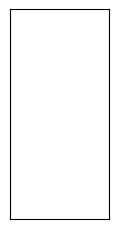

In [ ]:
# %% [markdown]
# ## 基础卷积神经网络实践：CIFAR-10图像分类
# 使用PyTorch实现简单的CNN

# %% [code]
# 1. 导入库
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# %% [code]
# 2. 数据加载与增强
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # RGB三通道归一化
])

# 下载数据集
train_dataset = datasets.CIFAR10(
    root='../data',
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.CIFAR10(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

# 创建数据加载器
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# 类别标签
classes = ('plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

# %% [code]
# 3. 定义CNN模型
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  # 输入通道3，输出32
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
print(model)

# %% [code]
# 4. 训练配置
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# %% [code]
# 5. 训练过程
num_epochs = 10
train_loss = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    train_loss.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

# %% [code]
# 6. 测试准确率
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


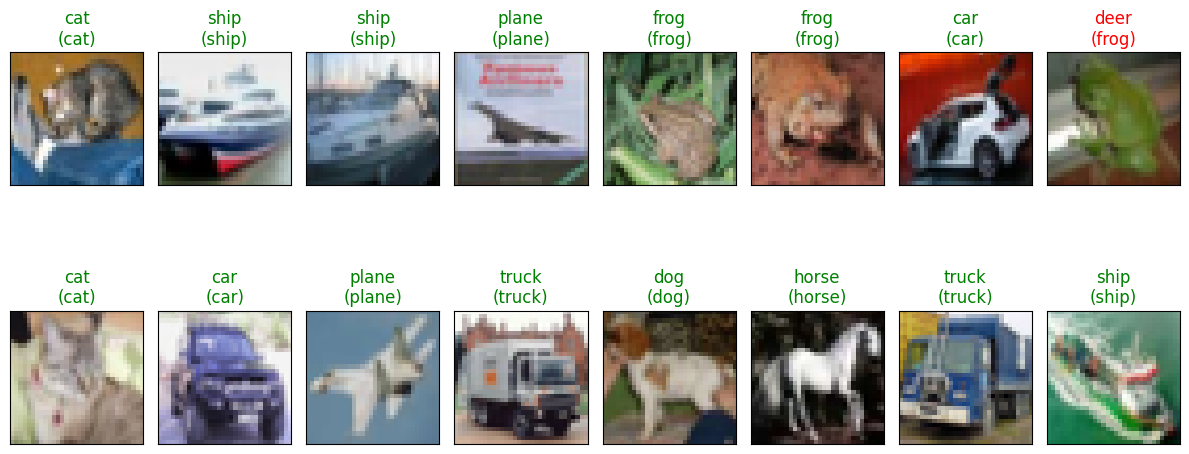

In [6]:
import numpy as np
# %% [code]
# 7. 可视化预测结果
def imshow(img):
    img = img * 0.5 + 0.5  # 反归一化
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

# 获取测试样本
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# 预测
outputs = model(images)
_, preds = torch.max(outputs, 1)

# 转换为CPU显示
images = images.cpu()
labels = labels.cpu()

# 显示结果
fig = plt.figure(figsize=(12, 6))
for idx in range(16):
    ax = fig.add_subplot(2, 8, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(f"{classes[preds[idx]]}\n({classes[labels[idx]]})", 
                 color=("green" if preds[idx]==labels[idx] else "red"))
plt.tight_layout()
plt.show()